# Custom Masked Multi-Head Attention - Benchmarking

This notebook compares three attention implementations:
1. **Reference** (simple JAX): Naive implementation for correctness checking
2. **JAX Pallas MHA** (attention.py): Standard causal attention from JAX
3. **Custom Masked MHA** (custom_attention.py): Our optimized custom mask implementation

## 1. Setup and Imports

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time
import sys

sys.path.insert(0, '.')

# Import attention implementations
from attention import mha as jax_pallas_mha
from custom_attention import custom_masked_mha

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX version: 0.8.2
Backend: gpu
Devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3), CudaDevice(id=4), CudaDevice(id=5), CudaDevice(id=6), CudaDevice(id=7)]


In [2]:
def reference_masked_attention(
    q: jnp.ndarray,
    k: jnp.ndarray,
    v: jnp.ndarray,
    history_len: int,
    candidate_len: int,
) -> jnp.ndarray:
    """
    Simple reference implementation.
    
    Args:
        q, k, v: [batch, seq_len, num_heads, head_dim]
        history_len: Number of history tokens (attend bidirectionally)
        candidate_len: Number of candidate tokens (attend to history only)
    """
    batch, seq_len, num_heads, head_dim = q.shape
    assert seq_len == history_len + candidate_len
    
    # Create mask: [seq_len, seq_len]
    mask = jnp.zeros((seq_len, seq_len), dtype=bool)
    mask = mask.at[:history_len, :history_len].set(True)  # History bidirectional
    mask = mask.at[history_len:, :history_len].set(True)  # Candidates to history
    
    # Transpose for einsum: [batch, num_heads, seq_len, head_dim]
    q_t = jnp.transpose(q, (0, 2, 1, 3))
    k_t = jnp.transpose(k, (0, 2, 1, 3))
    v_t = jnp.transpose(v, (0, 2, 1, 3))
    
    # Compute scores: [batch, num_heads, seq_len, seq_len]
    scores = jnp.einsum('bhqd,bhkd->bhqk', q_t, k_t) / jnp.sqrt(head_dim)
    
    # Apply mask
    mask_value = jnp.finfo(scores.dtype).min
    scores = jnp.where(mask[None, None, :, :], scores, mask_value)
    
    # Softmax and apply to values
    attn_weights = jax.nn.softmax(scores, axis=-1)
    output = jnp.einsum('bhqk,bhkd->bhqd', attn_weights, v_t)
    
    # Transpose back: [batch, seq_len, num_heads, head_dim]
    return jnp.transpose(output, (0, 2, 1, 3))

## 3. Correctness Test

Compare custom_masked_mha vs reference implementation.

In [3]:
def test_correctness():
    print("Testing Correctness")
    print("=" * 60)
    
    # Test configuration
    batch = 4
    history_len = 512
    candidate_len = 512
    seq_len = history_len + candidate_len
    num_heads = 8
    head_dim = 64
    
    print(f"Config: batch={batch}, history={history_len}, candidates={candidate_len}")
    print(f"        num_heads={num_heads}, head_dim={head_dim}\n")
    
    # Generate random inputs
    key = jax.random.PRNGKey(42)
    k1, k2, k3 = jax.random.split(key, 3)
    q = jax.random.normal(k1, (batch, seq_len, num_heads, head_dim))
    k = jax.random.normal(k2, (batch, seq_len, num_heads, head_dim))
    v = jax.random.normal(k3, (batch, seq_len, num_heads, head_dim))
    
    # Run reference
    print("Running reference implementation...")
    ref_out = reference_masked_attention(q, k, v, history_len, candidate_len)
    print(f"  Output shape: {ref_out.shape}")
    
    # Run custom implementation
    print("\nRunning custom Pallas implementation...")
    try:
        custom_out = custom_masked_mha(q, k, v, history_len, candidate_len)
        print(f"  Output shape: {custom_out.shape}")
        
        # Compare
        print("\nComparison:")
        max_diff = jnp.max(jnp.abs(ref_out - custom_out))
        mean_diff = jnp.mean(jnp.abs(ref_out - custom_out))
        
        print(f"  Max absolute difference:  {max_diff:.2e}")
        print(f"  Mean absolute difference: {mean_diff:.2e}")
        
        is_close = jnp.allclose(ref_out, custom_out, rtol=1e-4, atol=1e-3)
        if is_close:
            print(f"\n  ✓ PASSED: Outputs match!")
        else:
            print(f"\n  ✗ FAILED: Outputs differ!")
        
        return is_close
    
    except Exception as e:
        print(f"\n  ✗ ERROR: {e}")
        print("\nNote: Pallas GPU kernels may not work on CPU. Use GPU for full test.")
        return False

test_correctness()

Testing Correctness
Config: batch=4, history=512, candidates=512
        num_heads=8, head_dim=64

Running reference implementation...
  Output shape: (4, 1024, 8, 64)

Running custom Pallas implementation...
  Output shape: (4, 1024, 8, 64)

Comparison:
  Max absolute difference:  1.68e-04
  Mean absolute difference: 1.58e-05

  ✓ PASSED: Outputs match!


Array(True, dtype=bool)

## 4. Performance Benchmark

Compare performance of:
- **JAX Pallas MHA** (causal attention from attention.py)
- **Custom Masked MHA** (our implementation from custom_attention.py)

We vary history_len while keeping total seq_len fixed.

In [6]:
def benchmark_performance():
    print("Performance Benchmark")
    print("=" * 60)
    
    # Fixed parameters
    batch = 4
    seq_len = 1024
    num_heads = 8
    head_dim = 64
    num_runs = 10
    
    # Vary history length
    history_lengths = [128, 256, 384, 512, 640, 768, 896, 1024]
    
    results = {
        'history_len': [],
        'jax_pallas_time': [],
        'custom_time': [],
    }
    
    print(f"Config: batch={batch}, seq_len={seq_len}, num_heads={num_heads}, head_dim={head_dim}")
    print(f"Running {num_runs} iterations per configuration\n")
    print(f"{'History':>8} {'JAX Pallas':>12} {'Custom':>12}")
    print("-" * 50)
    
    for history_len in history_lengths:
        candidate_len = seq_len - history_len
        
        # Generate inputs
        key = jax.random.PRNGKey(42)
        k1, k2, k3 = jax.random.split(key, 3)
        q = jax.random.normal(k1, (batch, seq_len, num_heads, head_dim))
        k = jax.random.normal(k2, (batch, seq_len, num_heads, head_dim))
        v = jax.random.normal(k3, (batch, seq_len, num_heads, head_dim))
        
        # Benchmark JAX Pallas causal attention
        try:
            # Warmup
            for _ in range(5):
                _ = jax_pallas_mha(q, k, v, segment_ids=None, causal=False)
                jax.block_until_ready(_)
            
            # Benchmark
            start = time.time()
            for _ in range(num_runs):
                out = jax_pallas_mha(q, k, v, segment_ids=None, causal=False)
                jax.block_until_ready(out)
            jax_time = (time.time() - start) / num_runs
        except Exception as e:
            print(f"  ✗ JAX Pallas error: {e}")
            jax_time = None
        
        # Benchmark custom masked attention
        try:
            # Warmup
            _ = custom_masked_mha(q, k, v, history_len, candidate_len)
            jax.block_until_ready(_)
            
            # Benchmark
            start = time.time()
            for _ in range(num_runs):
                out = custom_masked_mha(q, k, v, history_len, candidate_len)
                jax.block_until_ready(out)
            custom_time = (time.time() - start) / num_runs
        except Exception as e:
            custom_time = None
        
        # Record results
        results['history_len'].append(history_len)
        results['jax_pallas_time'].append(jax_time * 1000 if jax_time else None)
        results['custom_time'].append(custom_time * 1000 if custom_time else None)
        
        # Print row
        jax_str = f"{jax_time*1000:9.2f}ms" if jax_time else "N/A"
        custom_str = f"{custom_time*1000:9.2f}ms" if custom_time else "N/A"
        
        print(f"{history_len:8d} {jax_str:>12} {custom_str:>12}")
    
    return results

benchmark_results = benchmark_performance()

Performance Benchmark
Config: batch=4, seq_len=1024, num_heads=8, head_dim=64
Running 10 iterations per configuration

 History   JAX Pallas       Custom
--------------------------------------------------
     128       0.42ms       0.19ms
     256       0.41ms       0.23ms
     384       0.41ms       0.25ms
     512       0.41ms       0.28ms
     640       0.41ms       0.31ms
     768       0.41ms       0.35ms
     896       0.41ms       0.37ms
    1024       0.41ms       0.46ms


## 5. Visualization

Plot history_len vs execution time.


Plot saved as 'attention_benchmark.png'


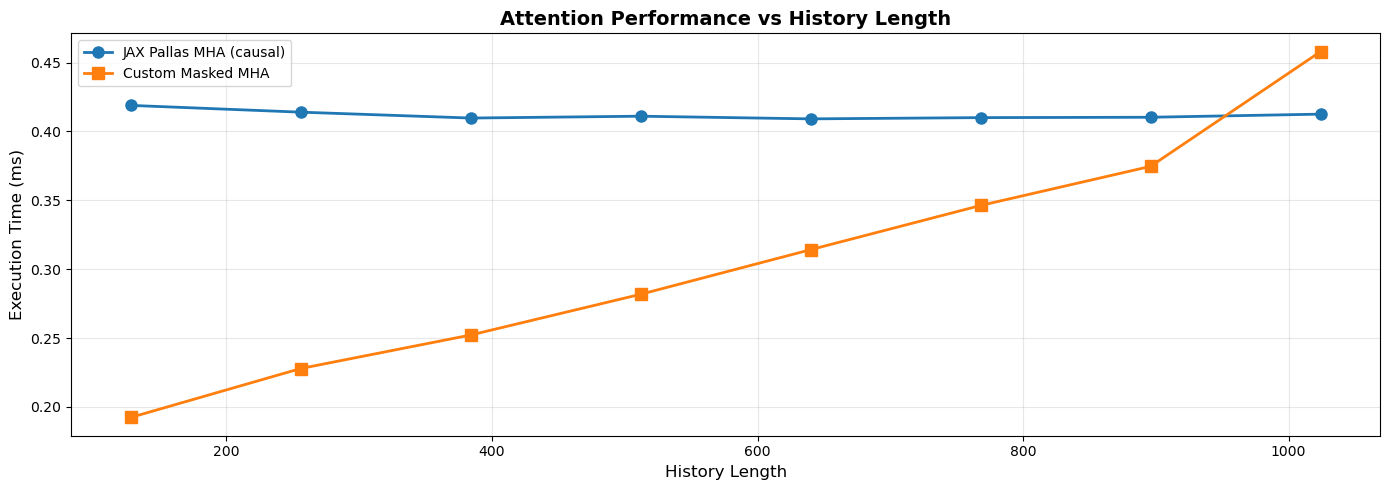

In [7]:
def plot_results(results):
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))
    
    history_lens = results['history_len']
    jax_times = results['jax_pallas_time']
    custom_times = results['custom_time']
    
    # Filter out None values
    valid_indices = [i for i in range(len(history_lens)) 
                     if jax_times[i] is not None and custom_times[i] is not None]
    
    if not valid_indices:
        print("No valid benchmark data to plot (likely running on CPU).")
        return
    
    history_lens_valid = [history_lens[i] for i in valid_indices]
    jax_times_valid = [jax_times[i] for i in valid_indices]
    custom_times_valid = [custom_times[i] for i in valid_indices]
    
    # Plot 1: Execution time
    ax1.plot(history_lens_valid, jax_times_valid, 'o-', label='JAX Pallas MHA (causal)', linewidth=2, markersize=8)
    ax1.plot(history_lens_valid, custom_times_valid, 's-', label='Custom Masked MHA', linewidth=2, markersize=8)
    ax1.set_xlabel('History Length', fontsize=12)
    ax1.set_ylabel('Execution Time (ms)', fontsize=12)
    ax1.set_title('Attention Performance vs History Length', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.savefig('attention_benchmark.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as 'attention_benchmark.png'")
    plt.show()

plot_results(benchmark_results)